# 90 Portfolio Inference Showcase

End-to-end output for recruiters and Kaggle readers.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import importlib

# Resolve project root in local or Kaggle runtime.
if Path("/kaggle/working").exists():
    ROOT = Path("/kaggle/working")
else:
    ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if (ROOT / "src").exists():
    SRC = ROOT / "src"
else:
    SRC = Path.cwd() / "src"
if str(SRC) not in sys.path and SRC.exists():
    sys.path.append(str(SRC))

if importlib.util.find_spec("laspy") is None:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "laspy[lazrs]"])

from lidar_roraima.config import ProjectConfig
cfg = ProjectConfig.from_root(ROOT)
cfg.ensure_dirs()

# Kaggle dataset fallback path.
RAW_DATA_DIR = cfg.raw_data_dir
for candidate in [
    Path("/kaggle/input/lidar-roraima-parime-research/lidar_data"),
    Path("/kaggle/input/lidar-roraima-parime-research"),
]:
    if candidate.exists():
        RAW_DATA_DIR = candidate
        break

print("ROOT:", ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
TRAIN_MAX_ROWS = None  # Set integer for constrained runtime, e.g. 1200000
cfg


ROOT: C:\Users\alexy\Documents\ChatGPT_projects\LIDAR RORAIMA
RAW_DATA_DIR: C:\Users\alexy\Documents\ChatGPT_projects\LIDAR RORAIMA\lidar_data


ProjectConfig(root_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA'), raw_data_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/lidar_data'), artifacts_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/artifacts'), manifests_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/artifacts/manifests'), features_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/artifacts/features'), models_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/artifacts/models'), inference_dir=WindowsPath('C:/Users/alexy/Documents/ChatGPT_projects/LIDAR RORAIMA/artifacts/inference'), random_seed=42)

In [2]:
canopy_path = cfg.inference_dir / "canopy_ensemble.parquet"
landcover_path = cfg.inference_dir / "landcover_ensemble.parquet"
canopy = pd.read_parquet(canopy_path) if canopy_path.exists() else pd.DataFrame()
landcover = pd.read_parquet(landcover_path) if landcover_path.exists() else pd.DataFrame()
canopy.shape, landcover.shape


((3673706, 5), (3673706, 5))

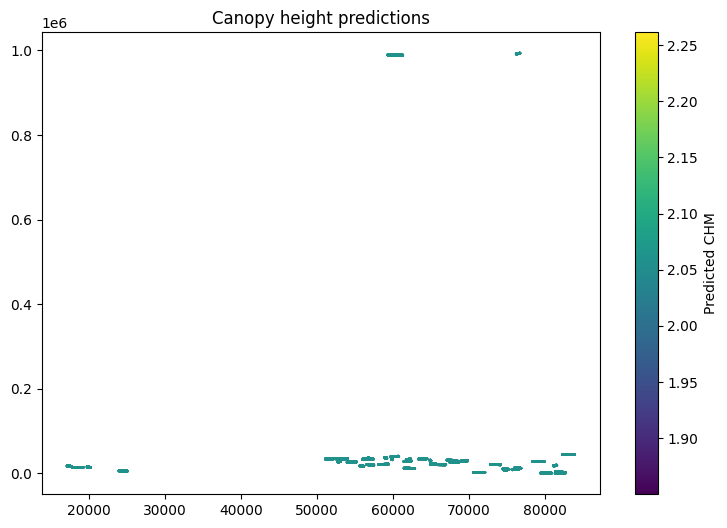

In [3]:
import matplotlib.pyplot as plt

if not canopy.empty:
    sample = canopy.sample(min(len(canopy), 20000), random_state=42)
    plt.figure(figsize=(9, 6))
    plt.scatter(sample["grid_x"], sample["grid_y"], c=sample["pred_chm"], s=1, cmap="viridis")
    plt.colorbar(label="Predicted CHM")
    plt.title("Canopy height predictions")
    plt.show()


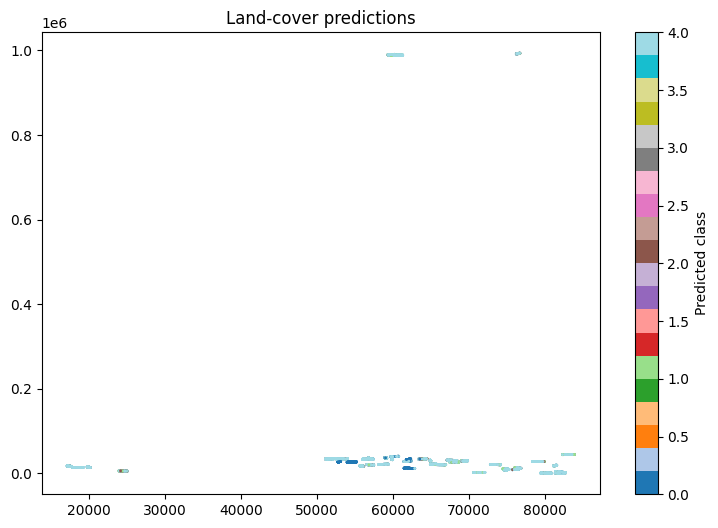

In [4]:
if not landcover.empty:
    sample = landcover.sample(min(len(landcover), 20000), random_state=42)
    plt.figure(figsize=(9, 6))
    plt.scatter(sample["grid_x"], sample["grid_y"], c=sample["pred_landcover"], s=1, cmap="tab20")
    plt.colorbar(label="Predicted class")
    plt.title("Land-cover predictions")
    plt.show()
